In [1]:
%load_ext autoreload
%autoreload 2
from L96 import *
from sklearn.decomposition import PCA
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
import matplotlib
from hmmlearn.hmm import GaussianHMM
from scipy.stats import gaussian_kde
import pickle
import re

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
import torch.nn as nn
class NNpAE(nn.Module):
    def __init__(self, past_timesteps, latent_dims, nodes_per_layer=16):
        super().__init__()

        self.past_timesteps = past_timesteps
        self.latent_dims = latent_dims
        self.nodes_per_layer = nodes_per_layer

        self.encoder = nn.Sequential(
            nn.Linear(self.past_timesteps, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 12),
            nn.ReLU(),
            nn.Linear(12, self.latent_dims)
        )
        self.neural_net = nn.Sequential(
            nn.Linear(latent_dims + 1, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, 1)
        )

        # Loss
        self.train_loss = []
        self.test_loss = []

        # R^2
        self.R2 = []

        # Metadata
        self.memory_cutoff = None
        self.tau = None
        self.model_name = 'NN+AE'

    def forward(self, x):
        x_past = x[:, :-1]
        x_present = torch.unsqueeze(x[:, -1], 1)
        # x_present = x[:, -1]

        latent_space = self.encoder(x_past)
        x_nn = torch.cat((latent_space, x_present), dim=1)
        y_pred = self.neural_net(x_nn)
        return y_pred


class FCNN(nn.Module):
    def __init__(self, past_timesteps=0, nodes_per_layer=16):
        super().__init__()
        self.nodes_per_layer = nodes_per_layer
        # Layers
        self.linear1 = nn.Linear(past_timesteps + 1, self.nodes_per_layer)  # number of past time steps the model receives as input
        self.linear2 = nn.Linear(self.nodes_per_layer, self.nodes_per_layer)
        self.linear3 = nn.Linear(self.nodes_per_layer, self.nodes_per_layer)
        self.linear4 = nn.Linear(self.nodes_per_layer, self.nodes_per_layer)
        self.linear5 = nn.Linear(self.nodes_per_layer, 1)  

        # Activation
        self.relu = nn.ReLU()

        # Loss
        self.train_loss = []
        self.test_loss = []

        # R^2
        self.R2 = []

        # Metadata
        self.memory_cutoff = None
        self.tau = None
        self.past_timesteps = past_timesteps
        self.model_name = None
        self.latent_dims = None

    def forward(self, x):
        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        x = self.relu(self.linear3(x))
        x = self.relu(self.linear4(x))
        x = self.linear5(x)
        return x
    
class NN(nn.Module):
    def __init__(self,past_timesteps, n_neighbours, nodes_per_layer=16):
        super().__init__()
        self.past_timesteps = past_timesteps
        self.n_neighbours = n_neighbours
        self.nodes_per_layer = nodes_per_layer

        self.neural_net = nn.Sequential(
            nn.Linear(self.past_timesteps + self.n_neighbours, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, 1)
        )

        # Loss
        self.train_loss = []
        self.test_loss = []

        # R^2
        self.R2 = []

        # Metadata
        self.memory_cutoff = None
        self.tau = None
        self.model_name = 'NN'
        self.latent_dims = 0

    def forward(self, x):
        y_pred = self.neural_net(x)
        return y_pred

In [2]:
def plot_regimes(X, title):
    smoothed_data = uniform_filter1d(X, size=80, axis=0)
    pca_smooth = PCA(n_components=4)
    pca_data_smooth = pca_smooth.fit_transform(smoothed_data)
    print(pca_smooth.explained_variance_ratio_)
    dim1 = (pca_data_smooth[:,0]**2 + pca_data_smooth[:,1]**2)**0.5
    dim2 = (pca_data_smooth[:,2]**2 + pca_data_smooth[:,3]**2)**0.5

    fig, ax = plt.subplots(figsize=(3,2),nrows=1,ncols=1)  
    im = ax.hist2d(x=dim1,y=dim2,bins=150,cmap='jet',density=True, vmin=0, vmax=0.08)
    ax.set(xlabel='||PC1, PC2||', ylabel='||PC3, PC4||', title=title)
    fig.colorbar(im[3], ax=ax)

    return fig, ax

In [3]:
def get_X(path=None, model_name='NN+AE'):
    if not path:
        il = 0 if model_name == 'baseline_nn' else 1000
        #il = 0 if model_name == 'baseline_nn' else 500
        #path = f'online_runs/{model_name}/input_lagg={il}/time=5000000_m=0.001_tau=0.001.pkl'
        path = f'online_runs/{model_name}/input_lagg={il}/time=50000000_m=0.001_tau=0.001.pkl'
    if '.nc' in path:
        L96 = L962LvlMem()
        XB = xr.load_dataset(path)
        L96._history_X = XB.X
        L96._history_B = XB.B
    else:
        with open(path, 'rb') as file:
                L96 = pickle.load(file)
            
    m = float(re.search(r'm=([\d.]+)', path).group(1))
    tau = float(re.search(r'tau=([\d.]+)', path).group(1)[:-1])
    #title = f'm={round(m, 3)}, tau={round(tau, 3)}'
    X = L96.history.X.values
    print(L96.dt, L96.save_dt)
    X = X[::5, :]

    return X

In [4]:
def cmap_discretize(cmap, N):
    """Return a discrete colormap from the continuous colormap cmap.
    
        cmap: colormap instance, eg. cm.jet. 
        N: number of colors.
    """
    if type(cmap) == str:
        cmap = get_cmap(cmap)
    colors_i = np.concatenate((np.linspace(0, 1., N), (0.,0.,0.,0.)))
    colors_rgba = cmap(colors_i)
    indices = np.linspace(0, 1., N+1)
    cdict = {}
    for ki, key in enumerate(('red','green','blue')):
        cdict[key] = [(indices[i], colors_rgba[i-1,ki], colors_rgba[i,ki]) for i in range(N+1)]
    # Return colormap object.
    return matplotlib.colors.LinearSegmentedColormap(cmap.name + "_%d"%N, cdict, 1024)

discretized_jet = cmap_discretize(matplotlib.cm.jet, 15)

def plot_regimes(X, title):
    smoothed_data = uniform_filter1d(X, size=80, axis=0)
    pca_smooth = PCA(n_components=4)
    pca_data_smooth = pca_smooth.fit_transform(smoothed_data)
    print(pca_smooth.explained_variance_ratio_)
    dim1 = (pca_data_smooth[:,0]**2 + pca_data_smooth[:,1]**2)**0.5
    dim2 = (pca_data_smooth[:,2]**2 + pca_data_smooth[:,3]**2)**0.5

    fig, ax = plt.subplots(figsize=(3,2),nrows=1,ncols=1)  
    im = ax.hist2d(x=dim1,y=dim2,bins=100,cmap=discretized_jet,density=True, vmin=0, vmax=0.08)
    ax.set(xlabel='||PC1, PC2||', ylabel='||PC3, PC4||', title=title)
    fig.colorbar(im[3], ax=ax)

    return fig, ax

0.001 0.001
[0.33109116 0.33074226 0.0821131  0.08126321]


(<Figure size 300x200 with 2 Axes>,
 <Axes: title={'center': '$true$'}, xlabel='||PC1, PC2||', ylabel='||PC3, PC4||'>)

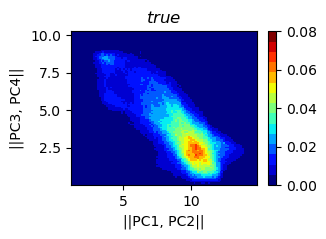

In [5]:
plot_regimes(get_X(path='online_runs/NO_PARAMETRIZATION/time=10000000_m=0.001_tau=0.001.pkl'), 
             title=r'$true$')

Memory steps: 1
0.001 0.001
[0.33953005 0.3381492  0.07378744 0.07347122]


(<Figure size 300x200 with 2 Axes>,
 <Axes: title={'center': '$\\phi_{8,1,1,ODE}$'}, xlabel='||PC1, PC2||', ylabel='||PC3, PC4||'>)

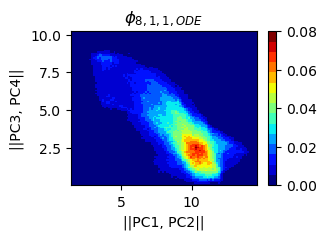

In [7]:
plot_regimes(get_X(path='online_runs/ODE_Z_online/input_lagg=1000/time=10000MTU_m=0.001_tau=0.001.nc'), title=r'$\phi_{8,1,1,ODE}$')

Memory steps: 1
0.001 0.001
[0.33115312 0.32804179 0.08401529 0.08295363]


(<Figure size 300x200 with 2 Axes>,
 <Axes: title={'center': '$\\phi_{8,1,1,ODE}$'}, xlabel='||PC1, PC2||', ylabel='||PC3, PC4||'>)

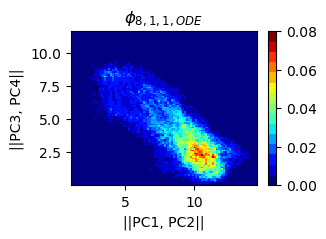

In [6]:
plot_regimes(get_X(path='online_runs/ODE_Z_online/input_lagg=1000/time=1000MTU_m=0.001_tau=0.001_less_data.nc'), title=r'$\phi_{8,1,1,ODE}$')

0.001 0.001
[0.32943562 0.32676763 0.08358123 0.08297143]


(<Figure size 300x200 with 2 Axes>,
 <Axes: title={'center': '$\\phi_{0,0,8}$'}, xlabel='||PC1, PC2||', ylabel='||PC3, PC4||'>)

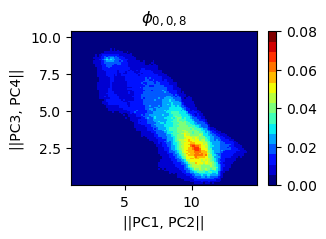

In [7]:
plot_regimes(get_X(path='online_runs/NN/input_lagg=0/time=10000MTU_m=0.001_tau=0.001.pkl'), 
             title=r'$\phi_{0,0,8}$')

Memory steps: 1
0.001 0.001
[0.28528985 0.28447535 0.13459626 0.13419188]


(<Figure size 300x200 with 2 Axes>,
 <Axes: title={'center': '$\\phi_{0,0,1}$'}, xlabel='||PC1, PC2||', ylabel='||PC3, PC4||'>)

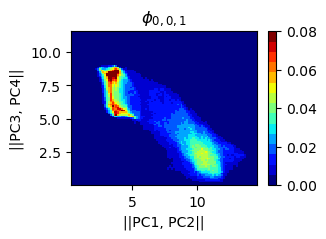

In [15]:
model = 'baseline_nn'
plot_regimes(get_X(path='online_runs/baseline_nn/input_lagg=0/time=10000MTU_m=0.001_tau=0.001.nc'), title=r'$\phi_{0,0,1}$')

0.001 0.001
[0.3183777  0.31756764 0.09561197 0.09499646]


(<Figure size 300x200 with 2 Axes>,
 <Axes: title={'center': '$\\phi_{0,1}$'}, xlabel='||PC1, PC2||', ylabel='||PC3, PC4||'>)

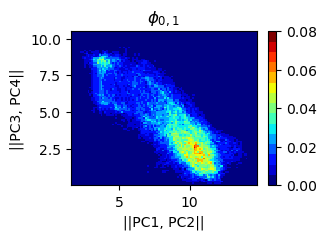

In [11]:
model = 'nn'
plot_regimes(get_X(model_name=model), title=r'$\phi_{0,1}$')

0.001 0.001
[0.33304249 0.32734976 0.08420216 0.08274804]


(<Figure size 300x200 with 2 Axes>,
 <Axes: title={'center': '$\\phi_{5,1}$'}, xlabel='||PC1, PC2||', ylabel='||PC3, PC4||'>)

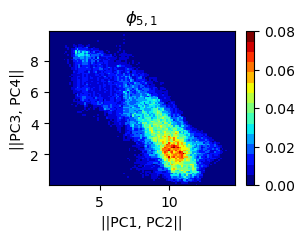

In [12]:
model = 'NN+AE_latent_dims=5'
plot_regimes(get_X(model_name=model), title=r'$\phi_{5,1}$')

0.001 0.001
[0.32895901 0.3252244  0.08822727 0.08464065]


(<Figure size 300x200 with 2 Axes>,
 <Axes: title={'center': '$\\phi_{3,1}$'}, xlabel='||PC1, PC2||', ylabel='||PC3, PC4||'>)

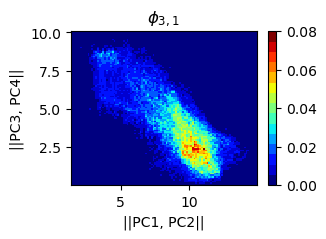

In [14]:
model = 'NN+AE_latent_dims=3'
plot_regimes(get_X(model_name=model), title=r'$\phi_{3,1}$')

[0.34306336 0.3428889  0.07230983 0.07216843]


(<Figure size 300x200 with 2 Axes>,
 <Axes: title={'center': 'true'}, xlabel='||PC1, PC2||', ylabel='||PC3, PC4||'>)

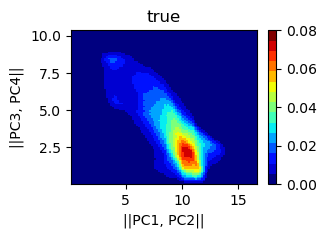

In [6]:
plot_regimes(X, 'true')
#plot_regimes(get_X(path='online_runs/NO_PARAMETRIZATION/time=10000000_m=0.001_tau=0.001.pkl'), 'true')

In [7]:
with open('online_runs/baseline_nn/input_lagg=0/time=50000000_m=0.001_tau=0.001.pkl', 'rb') as file:
    L96 = pickle.load(file)

: 

In [13]:
smoothed_data = uniform_filter1d(X, size=80, axis=0)

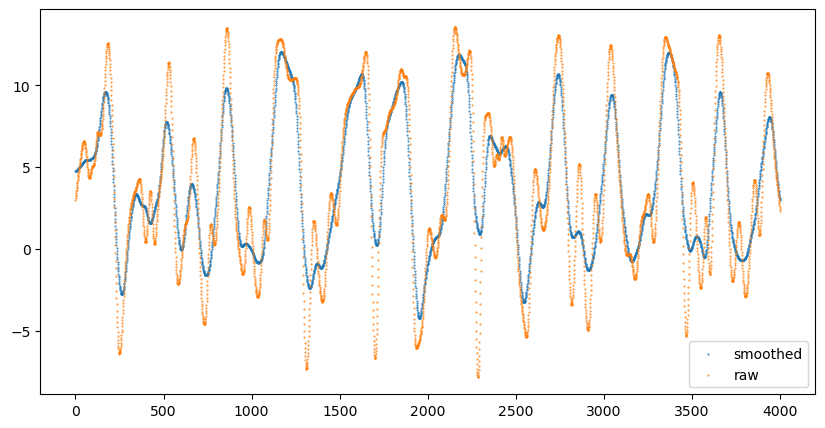

In [14]:
fig,ax = plt.subplots(figsize=(10,5),nrows=1,ncols=1)
ax.scatter(np.arange(0,4000),smoothed_data[:4000,1],s=0.2,label="smoothed")
ax.scatter(np.arange(0,4000),X[:4000,1],s=0.2,label="raw")
ax.legend()

In [15]:
pca_smooth = PCA(n_components=4)
pca_data_smooth = pca_smooth.fit_transform(smoothed_data)

In [16]:
smoothed_data.shape

(2000000, 8)

In [17]:
pca_smooth.explained_variance_ratio_

array([0.3322601 , 0.33188603, 0.08106696, 0.08060642])

In [18]:
dim1 = (pca_data_smooth[:,0]**2 + pca_data_smooth[:,1]**2)**0.5
dim2 = (pca_data_smooth[:,2]**2 + pca_data_smooth[:,3]**2)**0.5

In [19]:
def cmap_discretize(cmap, N):
    """Return a discrete colormap from the continuous colormap cmap.
    
        cmap: colormap instance, eg. cm.jet. 
        N: number of colors.
    """
    if type(cmap) == str:
        cmap = get_cmap(cmap)
    colors_i = np.concatenate((np.linspace(0, 1., N), (0.,0.,0.,0.)))
    colors_rgba = cmap(colors_i)
    indices = np.linspace(0, 1., N+1)
    cdict = {}
    for ki, key in enumerate(('red','green','blue')):
        cdict[key] = [(indices[i], colors_rgba[i-1,ki], colors_rgba[i,ki]) for i in range(N+1)]
    # Return colormap object.
    return matplotlib.colors.LinearSegmentedColormap(cmap.name + "_%d"%N, cdict, 1024)

In [20]:
discretized_jet = cmap_discretize(matplotlib.cm.jet, 15)
discretized_virids = cmap_discretize(matplotlib.cm.viridis, 15)

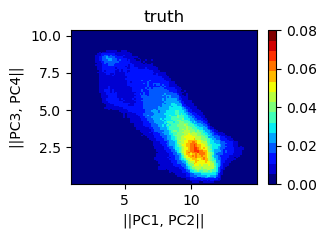

In [24]:
fig, ax = plt.subplots(figsize=(3,2),nrows=1,ncols=1)  
im = ax.hist2d(x=dim1,y=dim2,bins=100,cmap=discretized_jet,density=True, vmin=0, vmax=0.08)
ax.set(xlabel='||PC1, PC2||', ylabel='||PC3, PC4||', title=title)
fig.colorbar(im[3], ax=ax)

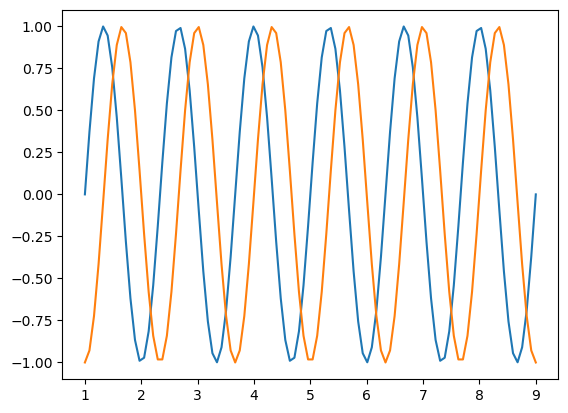

In [129]:
K = 8
Ks = np.linspace(1, K+1, 100)
for j in range(6, 7):
    s = np.cos(2 * np.pi * j * Ks /K )
    c = np.sin(2 * np.pi * j * Ks /K )
    plt.plot(Ks, s, label=f'j={j}')
    plt.plot(Ks, c, label=f'j={j}')


In [205]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import normalize
from hmmlearn.hmm import GaussianHMM

In [219]:
# Assuming X is your input array with shape (NT, K=8)
NT, K = X.shape
assert K == 8, "This version expects 8 L96 variables."

# Step 1: Anomalize
X_anom = X - np.mean(X, axis=0, keepdims=True)

# Step 2: Project into circular sine/cosine basis
u, v = [], []
for j in range(1, 5):
    s = np.cos(2 * np.pi * j * np.arange(K) / K)
    c = np.sin(2 * np.pi * j * np.arange(K) / K)
    s /= np.linalg.norm(s)
    c /= np.linalg.norm(c)
    u.append(X_anom @ s)
    v.append(X_anom @ c)

# Step 3: Compute radial coordinates (magnitude in each phase angle)
X_proj = np.sqrt(np.array(u)**2 + np.array(v)**2).T  # shape: (NT, 4)

# Step 4: Fit 2-cluster GMM
nclust = 2
gmm = GaussianMixture(n_components=nclust, max_iter=500, random_state=2)
gmm.fit(X_proj)

# Step 5: Initialize and fit HMM
hmm = GaussianHMM(n_components=nclust, covariance_type='full', n_iter=50, random_state=2)
hmm.startprob_ = normalize(np.random.rand(1, nclust))[0]
hmm.transmat_ = normalize(np.random.rand(nclust, nclust), axis=1)
hmm.means_ = gmm.means_
hmm.covars_ = gmm.covariances_

hmm.fit(X_proj)

# Step 6: Decode regime sequence
states = hmm.predict(X_proj)

# Optional: View results
print("Inferred transition matrix:\n", hmm.transmat_)
print("Regime time series (first 20):", states[:20])


Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'


Inferred transition matrix:
 [[0.98804713 0.01195287]
 [0.01044238 0.98955762]]
Regime time series (first 20): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
# 7. KDE for full distribution and each regime
def kde_2d(xy, grid_x, grid_y):
    kde = gaussian_kde(xy.T)
    X, Y = np.meshgrid(grid_x, grid_y)
    coords = np.vstack([X.ravel(), Y.ravel()])
    Z = kde(coords).reshape(X.shape)
    return X, Y, Z

# Use the first 2 components for 2D KDE
X2d = X_proj[:, :2]
pts1 = X2d[states == 0]
pts2 = X2d[states == 1]

# Grid setup
x_grid = np.linspace(0, 20, 100)
y_grid = np.linspace(0, 20, 100)

# KDEs
X1, Y1, Z_all = kde_2d(X2d, x_grid, y_grid)
_, _, Z_1 = kde_2d(pts1, x_grid, y_grid)
_, _, Z_2 = kde_2d(pts2, x_grid, y_grid)

# Normalize by regime size
Z_1 *= len(pts1) / len(X2d)
Z_2 *= len(pts2) / len(X2d)

# 8. Plot
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, Z, title in zip(axs, [Z_all, Z_1, Z_2], ['All Points', 'Regime 1', 'Regime 2']):
    c = ax.contourf(X1, Y1, Z, levels=30, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('Z_1')
    ax.set_ylabel('Z_2')
    fig.colorbar(c, ax=ax)

plt.tight_layout()
plt.show()

In [ ]:
# 7. KDE
def kde_contour_data(xy, grid_x, grid_y):
    kde = gaussian_kde(xy.T)
    Xg, Yg = np.meshgrid(grid_x, grid_y)
    coords = np.vstack([Xg.ravel(), Yg.ravel()])
    Z = kde(coords).reshape(Xg.shape)
    return Xg, Yg, Z

# Use first 2 components for 2D
X2d = X_proj[:, :2]
pts1 = X2d[states == 0]
pts2 = X2d[states == 1]

# Grid
x_grid = np.linspace(0, 20, 100)
y_grid = np.linspace(0, 20, 100)

# Contours
Xg, Yg, Z_all = kde_contour_data(X2d, x_grid, y_grid)
_, _, Z_1 = kde_contour_data(pts1, x_grid, y_grid)
_, _, Z_2 = kde_contour_data(pts2, x_grid, y_grid)

# Normalize regime-specific KDEs
Z_1 *= len(pts1) / len(X2d)
Z_2 *= len(pts2) / len(X2d)

In [220]:
# KDE function
def kde_contour_data(xy, grid_x, grid_y):
    kde = gaussian_kde(xy.T)
    Xg, Yg = np.meshgrid(grid_x, grid_y)
    coords = np.vstack([Xg.ravel(), Yg.ravel()])
    Z = kde(coords).reshape(Xg.shape)
    return Xg, Yg, Z

# Sampling helper function
def sample_data(x, max_points=5000):
    if len(x) > max_points:
        idx = np.random.choice(len(x), max_points, replace=False)
        return x[idx]
    return x

# Use first 2 components for 2D
X2d = X_proj[:, :2]
pts1 = X2d[states == 0]
pts2 = X2d[states == 1]

# Sampled subsets for faster KDE
X2d_sampled = sample_data(X2d)
pts1_sampled = sample_data(pts1)
pts2_sampled = sample_data(pts2)

# Grid
x_grid = np.linspace(0, 20, 100)
y_grid = np.linspace(0, 20, 100)

# Contours
Xg, Yg, Z_all = kde_contour_data(X2d_sampled, x_grid, y_grid)
_, _, Z_1 = kde_contour_data(pts1_sampled, x_grid, y_grid)
_, _, Z_2 = kde_contour_data(pts2_sampled, x_grid, y_grid)

# Normalize regime-specific KDEs
Z_1 *= len(pts1) / len(X2d)
Z_2 *= len(pts2) / len(X2d)


/tmp/ipykernel_1862073/2832900052.py:4: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(Xg, Yg, Z_all, levels=Nlevels, colors='gray', linestyles='dashed', linewidths=1, label='Unconditional')
/tmp/ipykernel_1862073/2832900052.py:5: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(Xg, Yg, Z_1, levels=Nlevels, colors='blue', linewidths=1.5, label='Regime 1')
/tmp/ipykernel_1862073/2832900052.py:6: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(Xg, Yg, Z_2, levels=Nlevels, colors='red', linewidths=1.5, label='Regime 2')


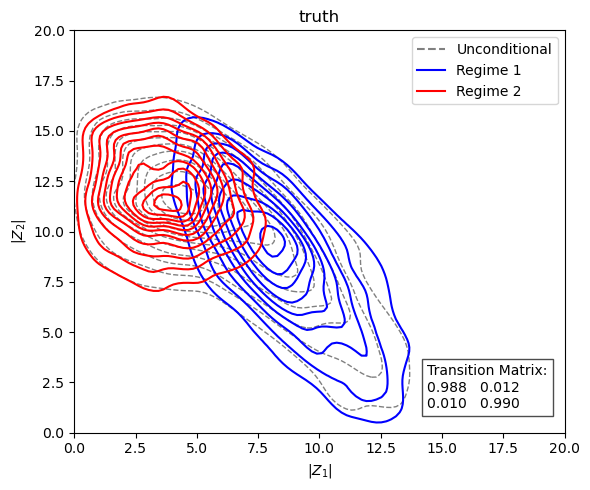

In [221]:
# 8. Plot
plt.figure(figsize=(6, 5))
Nlevels = 11
plt.contour(Xg, Yg, Z_all, levels=Nlevels, colors='gray', linestyles='dashed', linewidths=1, label='Unconditional')
plt.contour(Xg, Yg, Z_1, levels=Nlevels, colors='blue', linewidths=1.5, label='Regime 1')
plt.contour(Xg, Yg, Z_2, levels=Nlevels, colors='red', linewidths=1.5, label='Regime 2')

# Labels
plt.xlabel(r'$|Z_1|$')
plt.ylabel(r'$|Z_2|$')
plt.title(title)
plt.grid(False)

# Custom legend since plt.contour doesn't create one directly
from matplotlib.lines import Line2D
legend_lines = [
    Line2D([0], [0], color='gray', linestyle='--', label='Unconditional'),
    Line2D([0], [0], color='blue', label='Regime 1'),
    Line2D([0], [0], color='red', label='Regime 2')
]
plt.legend(handles=legend_lines)

# Add transition matrix text
transmat_text = '\n'.join(
    [f"{row[0]:.3f}   {row[1]:.3f}" for row in hmm.transmat_]
)
plt.text(0.72, 0.17, f"Transition Matrix:\n{transmat_text}",
         transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))


plt.tight_layout()
plt.show()